# Grid notation of permutations

## Libraries

In [1]:
import random
import itertools
import sympy
sympy.init_printing()
import sys
sys.path.append("../modules")
t = sympy.symbols('t')
from tqdm.notebook import tqdm

import Permutation as pm
from Grid_notation import *

%matplotlib inline
import matplotlib.pyplot as plt

# ----- Debugger -----
# from IPython.core.debugger import Pdb; Pdb().set_trace()

In [2]:
import numpy as np
# import matplotlib.pyplot as plt
from  matplotlib import patches
from matplotlib.figure import Figure
from matplotlib import rcParams
    
def zplane(mdict):
    """Plot the complex z-plane given a transfer function.
    """
    # get a figure/plot
    ax = plt.subplot(111)

    # create the unit circle
    uc = patches.Circle((0,0), radius=1, fill=False,
                        color='black', ls='dashed')
    ax.add_patch(uc)

    # Plot the points
    for v in mdict:
        z = complex(v)
        t1 = plt.plot(z.real, z.imag, 'go', ms=5, label=mdict[v])
        plt.setp( t1, markersize=10.0, markeredgewidth=1.0, markeredgecolor='k', markerfacecolor='g')

    ax.spines['left'].set_position('center')
    ax.spines['bottom'].set_position('center')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # set the ticks
    r = 1.5; plt.axis('scaled'); plt.axis([-r, r, -r, r])
    ticks = [-1, 1]; plt.xticks(ticks); plt.yticks(ticks)

    return mdict

## Sequence of reduction

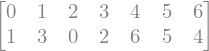

[[1, 3, 2, 0], [6, 4], [5]], 3
+---+---+---+---+---+---+---+
|   | 1 |   |   |   |   |   |
+---+---+---+---+---+---+---+
|   |   |   | 1 |   |   |   |
+---+---+---+---+---+---+---+
| 1 |   |   |   |   |   |   |
+---+---+---+---+---+---+---+
|   |   | 1 |   |   |   |   |
+---+---+---+---+---+---+---+
|   |   |   |   |   |   | 1 |
+---+---+---+---+---+---+---+
|   |   |   |   |   | 1 |   |
+---+---+---+---+---+---+---+
|   |   |   |   | 1 |   |   |
+---+---+---+---+---+---+---+


In [3]:
N = 7 #random.randint(2,20)
img = list(range(N)); random.shuffle(img)

prm = pm.Permutation(img)
display(sympy.Matrix(prm.two_line()))  # , prm.image, prm.size)
cd = pm.cycle_decomp(prm); print("{}, {}".format(cd, len(cd)))

G = Grid(prm)
G.show()

In [4]:
descending_seq = G.get_reduction()

total = 0
for d in descending_seq:
    
    if d["direction"] == None:
        mstr = "G =" 
    else:
        total += d["num"]
        mstr = "↓ {}  [{}]".format(d["direction"], total)
    print("\n {} \n".format(mstr))
    G = d["grid"]
    P = G.permutation.matrix()
    I = sympy.eye(len(P))
    D = (I-t*P).det()
    #---
    G.show(); display(D.factor())
#---    
print("\n |G| = {}".format(total+descending_seq[-1]["grid"].matrix[0][0]))


 G = 

+---+---+---+---+---+---+---+
|   | 1 |   |   |   |   |   |
+---+---+---+---+---+---+---+
|   |   |   | 1 |   |   |   |
+---+---+---+---+---+---+---+
| 1 |   |   |   |   |   |   |
+---+---+---+---+---+---+---+
|   |   | 1 |   |   |   |   |
+---+---+---+---+---+---+---+
|   |   |   |   |   |   | 1 |
+---+---+---+---+---+---+---+
|   |   |   |   |   | 1 |   |
+---+---+---+---+---+---+---+
|   |   |   |   | 1 |   |   |
+---+---+---+---+---+---+---+



 ↓ TL  [0] 

+---+---+---+---+---+
|   | 2 |   |   |   |
+---+---+---+---+---+
| 1 |   |   |   |   |
+---+---+---+---+---+
|   |   |   |   | 1 |
+---+---+---+---+---+
|   |   |   | 1 |   |
+---+---+---+---+---+
|   |   | 1 |   |   |
+---+---+---+---+---+



 ↓ TL  [0] 

+---+---+---+---+---+
|   | 1 |   |   |   |
+---+---+---+---+---+
| 1 |   |   |   |   |
+---+---+---+---+---+
|   |   |   |   | 1 |
+---+---+---+---+---+
|   |   |   | 1 |   |
+---+---+---+---+---+
|   |   | 1 |   |   |
+---+---+---+---+---+



 ↓ BR  [0] 

+---+---+---+
|   | 1 |   |
+---+---+---+
| 1 |   |   |
+---+---+---+
|   |   | 2 |
+---+---+---+



 ↓ TL  [0] 

+---+
| 3 |
+---+



 |G| = 3


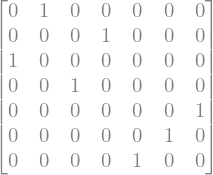

{-1: 2, 1: 3, -I: 1, I: 1}


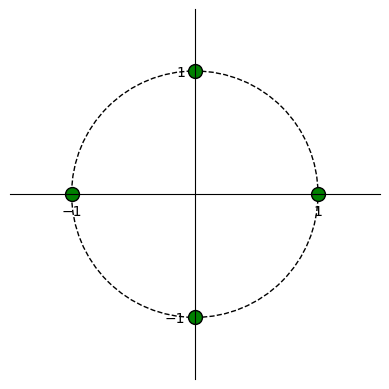

In [5]:
A = sympy.Matrix(prm.matrix()); display(A)
evs = A.eigenvals()
print(evs) #, A.diagonalize()[1])
    
zplane(evs)

I = sympy.eye(N)

dt = (I-t*A).det()
display(dt, dt.factor())

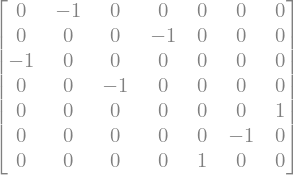

{-1: 3, 1: 2, -I: 1, I: 1}


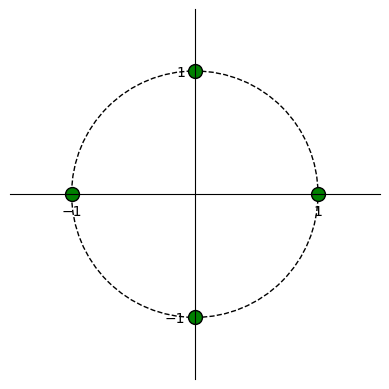

In [6]:
B = A.copy()
s = sympy.shape(B)[0]

for row, col in itertools.product(range(s),range(s)):
    entry = B[row,col]
    if entry == 1:
        B[row,col] *= (-1)**random.randint(0,1)
display(B)#, B.eigenvals()) #, B.diagonalize()[1])
evs = B.eigenvals(); print(evs)
zplane(evs)

dtt = (I-t*B).det(); display(dtt, dtt.factor())

# scratch 01

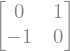

In [3]:
C = sympy.Matrix([[0,1],[-1,0]])
display(C, C.eigenvals())
    
D = (sympy.eye(2)-t*C).det()
display(D, D.factor())

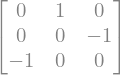

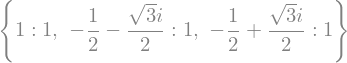

In [4]:
C = sympy.Matrix([[0,1,0],[0,0,-1],[-1,0,0]])
cs = sympy.shape(C)[0]
display(C, C.eigenvals())
    
D = (sympy.eye(cs)-t*C).det()
display(D, D.factor())

In [ ]:
C = sympy.Matrix([[0,0,1],[1,0,0],[0,-1,0]])
cs = sympy.shape(C)[0]
display(C, C.eigenvals())
    
D = (sympy.eye(cs)-t*C).det()
display(D, D.factor())

In [ ]:
C = sympy.Matrix([[0,1],[1,0]])
display(C, C.eigenvals())
    
D = (sympy.eye(2)-t*C).det()
display(D, D.factor())

In [ ]:
C = sympy.Matrix([[0,1,0],[0,0,1],[1,0,0]])
cs = sympy.shape(C)[0]
display(C, C.eigenvals())
    
D = (sympy.eye(cs)-t*C).det()
display(D, D.factor())

In [ ]:
np.matrix([[0,1,0],[0,0,1],[1,0,0]])
signlist = [1,-1,-1]
D = sympy.diag(*signlist)
display(D*C)
print((D*C).type())

In [ ]:
C = sympy.Matrix([[0,0,1],[1,0,0],[0,-1,0]])
cs = sympy.shape(C)[0]
display(C, C.eigenvals())
    
D = (sympy.eye(cs)-t*C).det()
display(D, D.factor())

In [ ]:
C = sympy.Matrix([[0,0,1],[0,1,0],[-1,0,0]])
cs = sympy.shape(C)[0]
display(C, C.eigenvals())
    
D = (sympy.eye(cs)-t*C).det()
display(D, D.factor())

In [ ]:
C = sympy.Matrix([[1,0],[0,-1]])
cs = sympy.shape(C)[0]
display(C, C.eigenvals())
    
D = (sympy.eye(cs)-t*C).det()
display(D, D.factor())

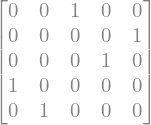

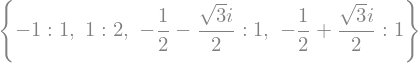

In [5]:
C = sympy.Matrix([[0,0,1,0,0],[0,0,0,0,1],[0,0,0,1,0],[1,0,0,0,0],[0,1,0,0,0]])
cs = sympy.shape(C)[0]
display(C, C.eigenvals())
    
D = (sympy.eye(cs)-t*C).det()
display(D, D.factor())

In [ ]:
C = sympy.Matrix([[0,0,0,1],[0,0,1,0],[0,1,0,0],[1,0,0,0]])
cs = sympy.shape(C)[0]
display(C, C.eigenvals())
    
D = (sympy.eye(cs)-t*C).det()
display(D, D.factor())

In [ ]:
C = sympy.Matrix([[1,0,0],[0,-1,0],[0,0,1]])
cs = sympy.shape(C)[0]
display(C, C.eigenvals())
    
D = (sympy.eye(cs)-t*C).det()
display(D, D.factor())

In [ ]:
C = sympy.Matrix([[1,0,0],[0,1,0],[0,0,-1]])
cs = sympy.shape(C)[0]
display(C, C.eigenvals())
    
D = (sympy.eye(cs)-t*C).det()
display(D, D.factor())

In [ ]:
C = sympy.Matrix([[1,0,0,0,0],[0,-1,0,0,0],[0,0,-1,0,0],[0,0,0,1,0],[0,0,0,0,-1]])
cs = sympy.shape(C)[0]
display(C, C.eigenvals())
    
D = (sympy.eye(cs)-t*C).det()
display(D, D.factor())

In [ ]:
C = sympy.Matrix([[0,0,1,0,0,0],[0,1,0,0,0,0],[-1,0,0,0,0,0],[0,0,0,-1,0,0],[0,0,0,0,1,0],[0,0,0,0,0,-1]])
cs = sympy.shape(C)[0]
display(C, C.eigenvals())
    
D = (sympy.eye(cs)-t*C).det()
display(D, D.factor())

In [ ]:
C = sympy.Matrix([[0,0,0,1,0],[0,0,0,0,1],[0,0,-1,0,0],[1,0,0,0,0],[0,1,0,0,0]])
cs = sympy.shape(C)[0]
display(C, C.eigenvals())
    
D = (sympy.eye(cs)-t*C).det()
display(D, D.factor())

In [ ]:
C = sympy.Matrix([[0,0,0,1,0],[0,0,0,0,1],[1,0,0,0,0],[0,-1,0,0,0],[0,0,-1,0,0]])
cs = sympy.shape(C)[0]
display(C, C.eigenvals())
    
D = (sympy.eye(cs)-t*C).det()
display(D, D.factor())

In [ ]:
C = sympy.Matrix([[0,-1,0],[0,0,-1],[1,0,0]])
cs = sympy.shape(C)[0]
display(C, C.eigenvals())
    
D = (sympy.eye(cs)-t*C).det()
display(D, D.factor())

In [ ]:
C = sympy.Matrix([[0,-1,0,0],[0,0,-1,0],[0,0,0,-1],[1,0,0,0]])
cs = sympy.shape(C)[0]
display(C, C.eigenvals())
    
D = (sympy.eye(cs)-t*C).det()
display(D, D.factor())

In [ ]:
C = sympy.Matrix([[0,0,0,0,-1,0,0],[0,0,0,0,0,-1,0],[0,0,0,0,0,0,-1],[1,0,0,0,0,0,0],[0,1,0,0,0,0,0],[0,0,1,0,0,0,0],[0,0,0,1,0,0,0]])
cs = sympy.shape(C)[0]
display(C, C.eigenvals())
    
D = (sympy.eye(cs)-t*C).det()
display(D, D.factor())

In [ ]:
C = sympy.Matrix([[0,0,0,0,-1,0],[0,0,0,0,0,-1],[0,0,0,-1,0,0],[1,0,0,0,0,0],[0,1,0,0,0,0],[0,0,1,0,0,0]])
cs = sympy.shape(C)[0]
display(C, C.eigenvals())
    
D = (sympy.eye(cs)-t*C).det()
display(D, D.factor())

In [ ]:
C = sympy.Matrix([[0,-1,0],[0,0,-1],[-1,0,0]])
cs = sympy.shape(C)[0]
display(C, C.eigenvals())
    
D = (sympy.eye(cs)-t*C).det()
display(D, D.factor())

In [ ]:
C = sympy.Matrix([[0,-1,0,0],[0,0,-1,0],[0,0,0,-1],[1,0,0,0]])
cs = sympy.shape(C)[0]
display(C, C.eigenvals())
    
D = (sympy.eye(cs)-t*C).det()
display(D, D.factor())

# scratch 02

In [6]:
def reduce_nagatively(mtx):
    size = len(mtx)
    for row in range(size-1):
        col = np.where(mtx[row] != 0)[0][0]
        if not col == 0:
            cc_num = mtx[row][col]
            ld_num = mtx[row+1][col-1]
            if (cc_num <= 1 and ld_num <= 1 and cc_num*ld_num !=0):
                mtx[row][col] = (abs(cc_num) + abs(ld_num))*(-1)
                mtx = np.delete(mtx, row + 1, 0)
                mtx = np.delete(mtx, col - 1, 1)
                break
    return mtx

def complete_reduce(matrix):
    mtx = matrix.copy()
    prev_size = len(mtx)
    while True:
        mtx = reduce_nagatively(mtx)
        if len(mtx) < prev_size:
            prev_size = len(mtx)
        else:
            break
    return mtx

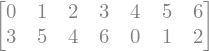

[[3, 6, 2, 4, 0], [5, 1]], 2
+---+---+---+---+---+
|   | 1 |   |   |   |
+---+---+---+---+---+
|   |   |   | 1 |   |
+---+---+---+---+---+
|   |   | 1 |   |   |
+---+---+---+---+---+
|   |   |   |   | 1 |
+---+---+---+---+---+
| 3 |   |   |   |   |
+---+---+---+---+---+


In [7]:
N = 7 #random.randint(2,20)
img = list(range(N)); random.shuffle(img)

prm = pm.Permutation(img)
display(sympy.Matrix(prm.two_line()))  # , prm.image, prm.size)
cd = pm.cycle_decomp(prm); print("{}, {}".format(cd, len(cd)))

G = Grid(prm)
G.show()

In [ ]:
P = sympy.Matrix(prm.matrix()); display(P, P.eigenvals())
size = sympy.shape(P)[0]
D = (sympy.eye(size)-t*P).det(); display(D, D.factor())

display(P.jordan_form()[1], size - (sympy.eye(size)-P).rank())
PP = (sympy.eye(size)-P)**2
display(PP, PP.rank())

In [ ]:
Q = sympy.Matrix(complete_reduce(G.matrix)); display(Q, Q.eigenvals())
E = (sympy.eye(sympy.shape(Q)[0])-t*Q).det(); display(E, E.factor())

In [ ]:
rows = []
for i in range(sympy.shape(Q)[0]):
    rows.append(list(map(lambda x: 1 if not x == 0 else x, Q.row(i))))

S = sympy.Matrix(rows); display(S, S.eigenvals())
K = (sympy.eye(sympy.shape(S)[0])-t*S).det(); display(K, K.factor())

In [ ]:
rows = []
for i in range(sympy.shape(Q)[0]):
    rows.append(list(map(lambda x: x/abs(x) if not x == 0 else x, Q.row(i))))

R = sympy.Matrix(rows); display(R, R.eigenvals())
F = (sympy.eye(sympy.shape(R)[0])-t*R).det(); display(F, F.factor())

# scratch 03

In [ ]:
def get_perm(monomial_matrix):
    d, p = monomial_matrix['diagonal'], monomial_matrix['permutation']
    size, pinv = sum([abs(v) for v in d]), p.inverse()
    
    I, A = sympy.eye(size), sympy.zeros(0,size)
    for k in range(len(d)):
        x = abs(d[k])
        sign = 1 if d[k]==x else -1
        prev = [abs(d[pinv.act(j)]) for j in range(p.act(k))]
        abov = [abs(d[i]) for i in range(k)]
        sp, sa = sum(prev), sum(abov)
    
        for i in range(x):
            start = sp if sign == 1 else sp+x-1
            A = A.row_insert(sa+i, I.row(start+sign*i))
    #-----
    img = [np.where(row > 0)[0][0] for row in np.array(A)]
    return pm.Permutation(img)

In [ ]:
my_img = [2,0,3,1]
my_perm = pm.Permutation(my_img)
my_mm = {'diagonal': [-5,3,-2,1], 'permutation': my_perm}

In [ ]:
my_perm = get_perm(my_mm)
display(my_perm)
print(len(pm.cycle_decomp(my_perm)))

In [ ]:
a,b,c,r = 5, 3, 2, 1

mymm = {'diagonal': [-a,b,c,-a,-(a-r),c,b,-(a-r),-2*r], 'permutation': pm.Permutation([8,2,1,5,3,7,6,0,4])}
gg = Grid(get_perm(mymm))
gg.show()

In [ ]:
for count in tqdm(range(100)):
    N = 8
    c,b = random.randint(1,N), random.randint(1,N)
    r = c + random.randint(1,int(N/2))
    a = r + random.randint(1,int(N/2))
    if (a-r<0 or r-c<0): raise Exception("a<r or r<c") 
    mm1 = {'diagonal': [-a,b,c,-a,-(a-r),c,b,-(a-r),-2*r], 'permutation': pm.Permutation([8,2,1,5,3,7,6,0,4])}
    #-----
    X, Y = b%(r-c), (a-r)%(2*r)
    Xi, Yi = (r-c)-X, (2*r)-Y
    mm2 = {'diagonal': [-Xi,-X,-c,-Xi,-X,-c,Y,-Y,-Yi], 'permutation': pm.Permutation([6,7,8,3,4,5,0,1,2])}
    #-----
    nums = []
    for mm in [mm1,mm2]:
        nums.append(len(pm.cycle_decomp(get_perm(mm))))
    #-----

    # if count%10 == 0: print(int(count/10))
    if not nums[0] == nums[1]: print("nums are different!! {},(a,b,c,r)={}".format(nums,[a,b,c,r]))